C:\Users\felip\AppData\Local\Temp\ipykernel_19216\416586273.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cooperar'] = pd.to_numeric(df_clean['Cooperar'])


Tabla 1: Cooperación por Dilema
       Dilema  N_Sujetos  Mean_Cooperacion       SEM
0  Bloque_CON         40           0.60625  0.049209
1  Bloque_SIN         40           0.70000  0.052772

Tabla 2: Cooperación por Gap_Size
   Gap_Size  N_Sujetos  Mean_Cooperacion       SEM
0       0.0         40          0.637500  0.049889
1    1000.0         40          0.641667  0.056472
2    1200.0         40          0.691667  0.055196
3    2000.0         40          0.616667  0.050000
4    2400.0         40          0.600000  0.056235


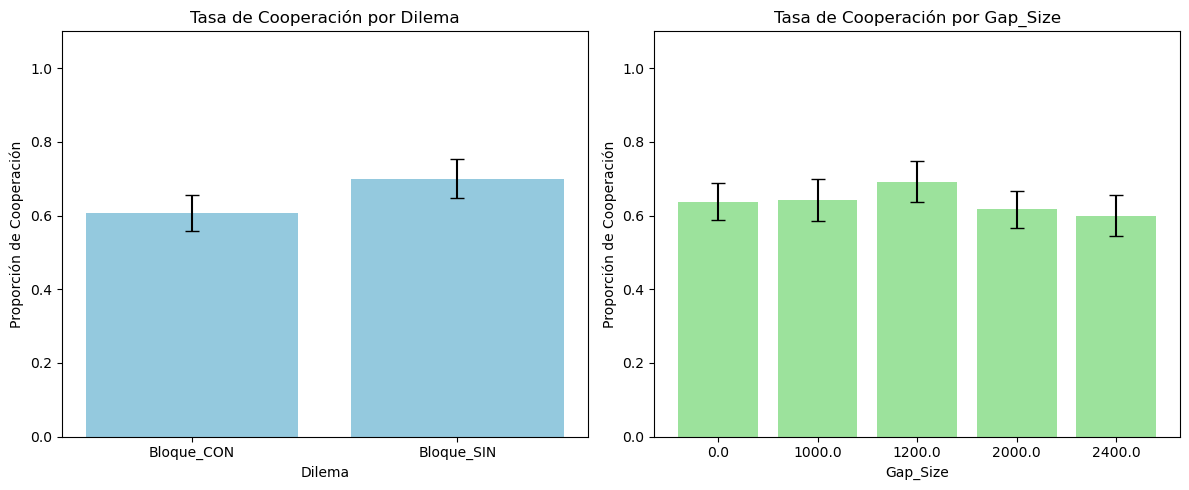

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_coop = pd.read_csv('Base_coop.csv')
df_clean = df_coop.dropna(subset=['Cooperar'])
# Ensure Cooperar is numeric
df_clean['Cooperar'] = pd.to_numeric(df_clean['Cooperar'])

# --- Analysis 1: Dilema ---
# Calculate mean cooperation per subject per Dilema
df_subj_dilema = df_clean.groupby(['ID_Sujeto', 'Dilema'])['Cooperar'].mean().reset_index()

# Calculate descriptive stats across subjects
stats_dilema = df_subj_dilema.groupby('Dilema')['Cooperar'].agg(['count', 'mean', 'sem']).reset_index()
stats_dilema.columns = ['Dilema', 'N_Sujetos', 'Mean_Cooperacion', 'SEM']

# --- Analysis 2: Gap_Size ---
# Calculate mean cooperation per subject per Gap_Size
df_subj_gap = df_clean.groupby(['ID_Sujeto', 'Gap_Size'])['Cooperar'].mean().reset_index()

# Calculate descriptive stats across subjects
stats_gap = df_subj_gap.groupby('Gap_Size')['Cooperar'].agg(['count', 'mean', 'sem']).reset_index()
stats_gap.columns = ['Gap_Size', 'N_Sujetos', 'Mean_Cooperacion', 'SEM']

# --- Print Tables ---
print("Tabla 1: Cooperación por Dilema")
print(stats_dilema)
print("\nTabla 2: Cooperación por Gap_Size")
print(stats_gap)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Dilema
sns.barplot(x='Dilema', y='Mean_Cooperacion', data=stats_dilema, ax=axes[0], capsize=0.1, color='skyblue')
# Add error bars manually since we are plotting from summary stats
axes[0].errorbar(x=range(len(stats_dilema)), y=stats_dilema['Mean_Cooperacion'], 
                 yerr=stats_dilema['SEM'], fmt='none', c='black', capsize=5)
axes[0].set_title('Tasa de Cooperación por Dilema')
axes[0].set_ylabel('Proporción de Cooperación')
axes[0].set_ylim(0, 1.1)

# Plot 2: Gap_Size
# Treat Gap_Size as categorical for the plot order usually
sns.barplot(x='Gap_Size', y='Mean_Cooperacion', data=stats_gap, ax=axes[1], capsize=0.1, color='lightgreen')
axes[1].errorbar(x=range(len(stats_gap)), y=stats_gap['Mean_Cooperacion'], 
                 yerr=stats_gap['SEM'], fmt='none', c='black', capsize=5)
axes[1].set_title('Tasa de Cooperación por Gap_Size')
axes[1].set_ylabel('Proporción de Cooperación')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('cooperacion_plots.png')

# Save stats to csv for user if needed (optional, but good practice)
#stats_dilema.to_csv('stats_dilema.csv', index=False)
#stats_gap.to_csv('stats_gap_size.csv', index=False)

Tabla: Tasa de Mantiene (Cooperación) por Gap_Size y Dilema
       Dilema  Gap_Size  N_Sujetos  Tasa_Mantiene       SEM
0  Bloque_CON       0.0         40        0.61875  0.049829
1  Bloque_CON    1000.0         40        0.61250  0.063265
2  Bloque_CON    1200.0         40        0.65000  0.062532
3  Bloque_CON    2000.0         40        0.58750  0.053372
4  Bloque_CON    2400.0         40        0.55000  0.058835
5  Bloque_SIN       0.0         40        0.67500  0.063423
6  Bloque_SIN    1000.0         40        0.70000  0.073380
7  Bloque_SIN    1200.0         40        0.77500  0.066867
8  Bloque_SIN    2000.0         40        0.67500  0.075000
9  Bloque_SIN    2400.0         40        0.70000  0.073380


C:\Users\felip\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1174: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
C:\Users\felip\anaconda3\lib\site-packages\matplotlib\axes\_axes.py:1175: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


<Figure size 1000x600 with 0 Axes>

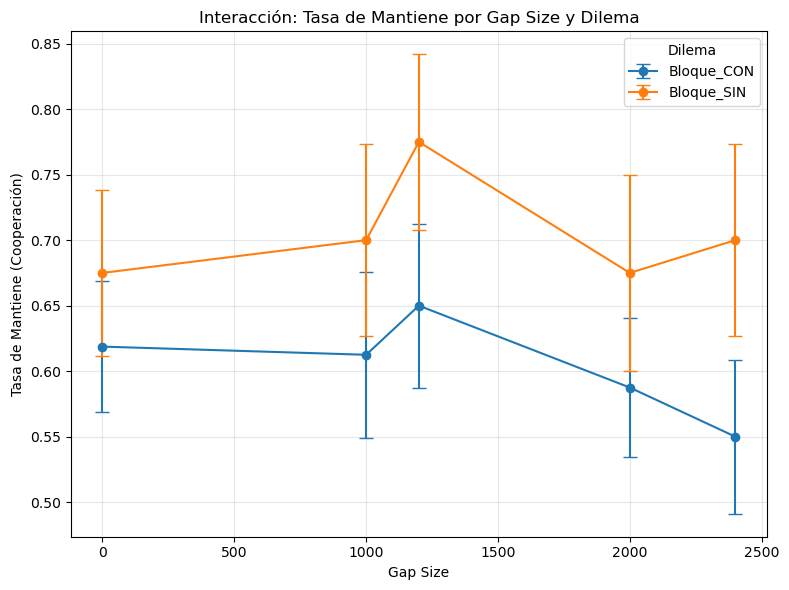

In [4]:
# --- Analysis: Interaction Gap_Size x Dilema ---
# Calculate mean per subject first (repeated measures adjustment)
df_subj = df_clean.groupby(['ID_Sujeto', 'Dilema', 'Gap_Size'])['Cooperar'].mean().reset_index()

# Calculate descriptive stats across subjects
stats_interaction = df_subj.groupby(['Dilema', 'Gap_Size'])['Cooperar'].agg(['count', 'mean', 'sem']).reset_index()
stats_interaction.columns = ['Dilema', 'Gap_Size', 'N_Sujetos', 'Tasa_Mantiene', 'SEM']

# Print Table
print("Tabla: Tasa de Mantiene (Cooperación) por Gap_Size y Dilema")
print(stats_interaction)

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Create the interaction plot
# Using seaborn pointplot or lineplot is best for interactions
sns.lineplot(x='Gap_Size', y='Tasa_Mantiene', hue='Dilema', data=stats_interaction, marker='o', err_style='bars')

# Add error bars manually if lineplot doesn't handle aggregated data with SEM easily
# Actually, pointplot is better for this summary data structure
plt.clf() # Clear
plt.figure(figsize=(8, 6))

# We can plot directly from the subject-level data to let seaborn handle CI/Error bars (Standard Error is default for pointplot usually, or ci=68 for SEM equivalent, or we use the pre-calculated stats)
# Let's plot from pre-calculated stats to be precise with SEM
colors = {'Bloque_SIN': 'blue', 'Bloque_CON': 'red'}

for dilema in stats_interaction['Dilema'].unique():
    subset = stats_interaction[stats_interaction['Dilema'] == dilema]
    plt.errorbar(x=subset['Gap_Size'], y=subset['Tasa_Mantiene'], yerr=subset['SEM'], 
                 label=dilema, fmt='-o', capsize=5)

plt.xlabel('Gap Size')
plt.ylabel('Tasa de Mantiene (Cooperación)')
plt.title('Interacción: Tasa de Mantiene por Gap Size y Dilema')
plt.legend(title='Dilema')
plt.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('interaccion_mantiene.png')

Tabla: Tasa de Cooperación por Dilema_Opcion (1 vs 2)
  Dilema_Opcion  N_Sujetos  Tasa_Cooperacion       SEM
0             1         40          0.570833  0.060532
1             2         40          0.641667  0.062745


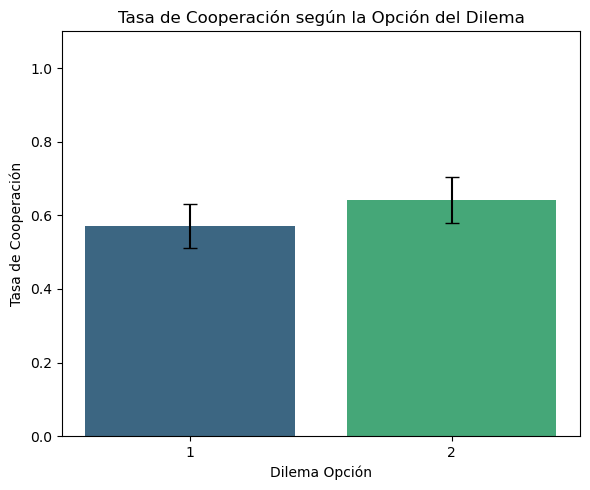

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_coop = pd.read_csv('Base_coop.csv')

# Filter for Dilema_Opcion 1 and 2
# We treat '1' and '2' as strings since they were read as objects in previous steps (['-' '2' '1'])
# Just in case they are integers, we can cast or check.
df_filtered = df_coop[df_coop['Dilema_Opcion'].isin(['1', '2', 1, 2])].copy()

# Ensure Cooperar is numeric
df_filtered['Cooperar'] = pd.to_numeric(df_filtered['Cooperar'])

# --- Analysis ---
# Calculate mean per subject first
df_subj = df_filtered.groupby(['ID_Sujeto', 'Dilema_Opcion'])['Cooperar'].mean().reset_index()

# Calculate descriptive stats across subjects
stats_opcion = df_subj.groupby('Dilema_Opcion')['Cooperar'].agg(['count', 'mean', 'sem']).reset_index()
stats_opcion.columns = ['Dilema_Opcion', 'N_Sujetos', 'Tasa_Cooperacion', 'SEM']

# Print Table
print("Tabla: Tasa de Cooperación por Dilema_Opcion (1 vs 2)")
print(stats_opcion)

# --- Plotting ---
plt.figure(figsize=(6, 5))
sns.barplot(x='Dilema_Opcion', y='Tasa_Cooperacion', data=stats_opcion, capsize=0.1, palette='viridis')

# Add error bars manually
plt.errorbar(x=range(len(stats_opcion)), y=stats_opcion['Tasa_Cooperacion'], 
             yerr=stats_opcion['SEM'], fmt='none', c='black', capsize=5)

plt.xlabel('Dilema Opción')
plt.ylabel('Tasa de Cooperación')
plt.title('Tasa de Cooperación según la Opción del Dilema')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('cooperacion_dilema_opcion.png')

stats_opcion.to_csv('stats_dilema_opcion.csv', index=False)

Tabla: Tasa de Mantiene (Cooperación) por Gap_Size y Dilema_Opcion
   Gap_Size Dilema_Opcion  N_Sujetos  Tasa_Mantiene       SEM
0       0.0             1         40         0.5625  0.069770
1       0.0             2         40         0.6750  0.068290
2    1000.0             1         40         0.6000  0.078446
3    1000.0             2         40         0.6250  0.077522
4    1200.0             1         40         0.6750  0.075000
5    1200.0             2         40         0.6250  0.077522
6    2000.0             1         40         0.4750  0.079964
7    2000.0             2         40         0.7000  0.073380
8    2400.0             1         40         0.5500  0.079663
9    2400.0             2         40         0.5500  0.079663


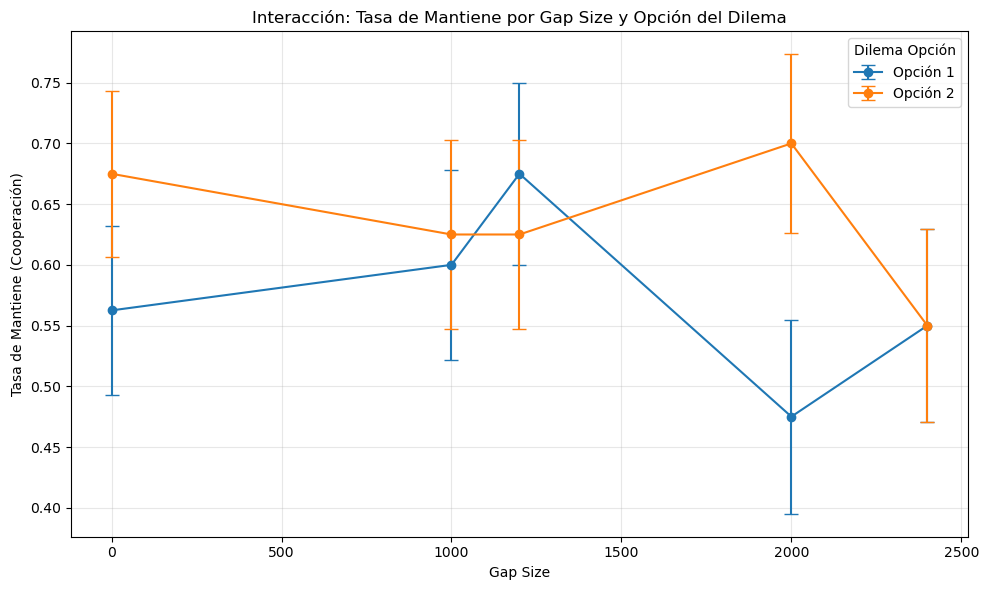

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df_coop = pd.read_csv('Base_coop.csv')

# Filter for Dilema_Opcion 1 and 2
df_filtered = df_coop[df_coop['Dilema_Opcion'].isin(['1', '2', 1, 2])].copy()

# Ensure Cooperar is numeric
df_filtered['Cooperar'] = pd.to_numeric(df_filtered['Cooperar'])

# Ensure Gap_Size is present (drop NaNs if any for this analysis)
df_filtered = df_filtered.dropna(subset=['Gap_Size'])

# --- Analysis: Interaction Gap_Size x Dilema_Opcion ---
# Calculate mean per subject first
df_subj = df_filtered.groupby(['ID_Sujeto', 'Gap_Size', 'Dilema_Opcion'])['Cooperar'].mean().reset_index()

# Calculate descriptive stats across subjects
stats_interaction_op = df_subj.groupby(['Gap_Size', 'Dilema_Opcion'])['Cooperar'].agg(['count', 'mean', 'sem']).reset_index()
stats_interaction_op.columns = ['Gap_Size', 'Dilema_Opcion', 'N_Sujetos', 'Tasa_Mantiene', 'SEM']

# Print Table
print("Tabla: Tasa de Mantiene (Cooperación) por Gap_Size y Dilema_Opcion")
print(stats_interaction_op)

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Use lineplot to show the trend across Gap Sizes for each Option
# We plot directly from the stats dataframe to control error bars precisely
for opcion in stats_interaction_op['Dilema_Opcion'].unique():
    subset = stats_interaction_op[stats_interaction_op['Dilema_Opcion'] == opcion]
    # Label for legend
    label_text = f"Opción {opcion}"
    plt.errorbar(x=subset['Gap_Size'], y=subset['Tasa_Mantiene'], yerr=subset['SEM'], 
                 label=label_text, fmt='-o', capsize=5)

plt.xlabel('Gap Size')
plt.ylabel('Tasa de Mantiene (Cooperación)')
plt.title('Interacción: Tasa de Mantiene por Gap Size y Opción del Dilema')
plt.legend(title='Dilema Opción')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('interaccion_mantiene_opcion.png')

stats_interaction_op.to_csv('tabla_mantiene_gap_opcion.csv', index=False)